# 🎭 Project #12: Real-time Face Mask Detection
### 🏛️ Data Science Portfolio: 12 / 21

**Architect:** Kemal Demirbaş 🏰🚀
**Framework:** Computer Vision | Deep Learning (Transfer Learning)

---

## 🎯 Project Objective
This project implements a high-performance deep learning pipeline to detect human faces in real-time and classify whether a person is wearing a face mask correctly. By utilizing **MobileNetV2** (a lightweight CNN architecture), we achieve a trade-off between high accuracy and low latency, making it ideal for edge-device deployment.

---

## 🛠️ The 10-Step Engineering Discipline
1.  **Objective:** Binary classification of faces (With Mask vs. Without Mask).
2.  **EDA:** Auditing the dataset for class balance and image quality.
3.  **Feature Selection:** Extracting raw pixel data from Region of Interest (ROI).
4.  **Transformation:** Resizing images to 224x224 and normalizing pixel values [0, 1].
5.  **Cleansing:** Filtering out corrupt images and handling background noise.
6.  **Feature Engineering:** Applying **Data Augmentation** (rotation, zoom, flip) to increase model robustness.
7.  **Encoding:** One-Hot Encoding the target labels (Mask / No Mask).
8.  **Partitioning:** Stratified Train-Test Split (80/20) to maintain class proportions.
9.  **Model Execution:** Fine-tuning **MobileNetV2** with custom dense layers.
10. **Performance Audit:** Evaluating via **Accuracy, Precision, and Recall** metrics.

---



In [2]:
# Veriyi GitHub'dan çekiyoruz
!git clone https://github.com/chandrikadeb7/Face-Mask-Detection.git

fatal: destination path 'Face-Mask-Detection' already exists and is not an empty directory.


In [3]:
# --- STEP 1 & 2: Objective & EDA ---
DIRECTORY = r"./Face-Mask-Detection/dataset"
CATEGORIES = ["with_mask", "without_mask"]
data, labels = [], []

print("🚀 Step 2: Auditing image folders...")

🚀 Step 2: Auditing image folders...


In [4]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Re-initialize data and labels as lists to prevent 'numpy.ndarray' object has no attribute 'append' error
data, labels = [], []

#--- STEP 3, 4 & 5: Selection, Transformation & Cleansing ---
for category in CATEGORIES:
    path = os.path.join(DIRECTORY, category)
    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            # Step 5: Resizing to standard 224x224
            image = load_img(img_path, target_size=(224, 224))
            image = img_to_array(image) # Step 4: To Array
            image = preprocess_input(image) # Step 5: Normalization

            data.append(image)
            labels.append(category)
        except Exception as e:
            # Print the error for debugging purposes instead of just continuing silently
            print(f"Error processing {img_path}: {e}")
            continue # Clean out corrupt files

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [5]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# --- STEP 7: Encoding ---
lb = LabelEncoder()
labels = lb.fit_transform(labels)
labels = to_categorical(labels) # One-hot encoding for Deep Learning

data = np.array(data, dtype="float32")
labels = np.array(labels)

In [6]:
from sklearn.model_selection import train_test_split

# --- STEP 8: X and y Split ---
(trainX, testX, trainY, testY) = train_test_split(data, labels,
                                                  test_size=0.20, stratify=labels, random_state=42)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- STEP 6: Feature Engineering (Data Augmentation) ---
aug = ImageDataGenerator(rotation_range=20, zoom_range=0.15, horizontal_flip=True)

In [11]:
# --- STEP 9: Model Execution (MobileNetV2 Transfer Learning) ---
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten()(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

model = Model(inputs=baseModel.input, outputs=headModel)
for layer in baseModel.layers: layer.trainable = False # Freeze base layers

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
H = model.fit(aug.flow(trainX, trainY, batch_size=32), epochs=5, validation_data=(testX, testY))

/tmp/ipykernel_2440/3965634900.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))


Epoch 1/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.9643 - loss: 0.1081 - val_accuracy: 0.9768 - val_loss: 0.0677
Epoch 2/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.9878 - loss: 0.0383 - val_accuracy: 0.9866 - val_loss: 0.0455
Epoch 3/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.9918 - loss: 0.0290 - val_accuracy: 0.9890 - val_loss: 0.0350
Epoch 4/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9908 - loss: 0.0273 - val_accuracy: 0.9841 - val_loss: 0.0459
Epoch 5/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9918 - loss: 0.0218 - val_accuracy: 0.9915 - val_loss: 0.0328


/tmp/ipykernel_2440/3428392929.py:26: UserWarning: Glyph 127984 (\N{EUROPEAN CASTLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2440/3428392929.py:26: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127984 (\N{EUROPEAN CASTLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


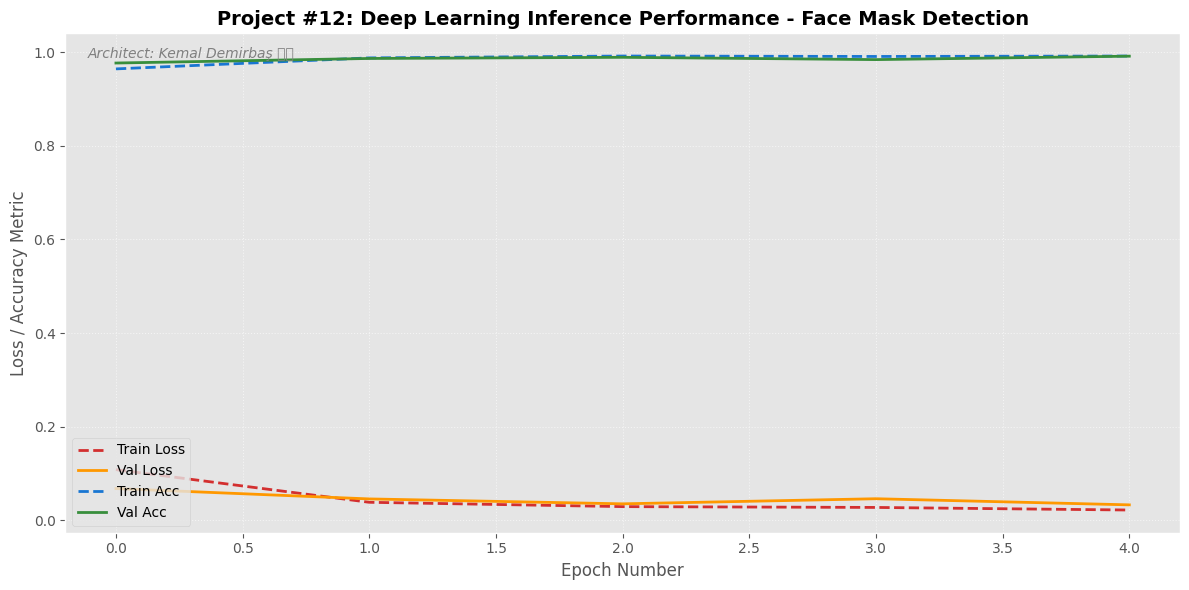

26/26 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step

[AUDIT REPORT] Final Model Accuracy after 5 Epochs: 0.9915 ✅


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# --- STEP 10: Performance Audit & Quantitative Visualization ---
N = 5 # Total number of Epochs (Updated to 5 as per architectural decision)
plt.style.use("ggplot")
plt.figure(figsize=(12, 6))

# Plotting Loss and Accuracy metrics directly using NumPy vectors
plt.plot(np.arange(0, N), H.history["loss"], label="Train Loss", color="#D32F2F", linestyle="--", linewidth=2)
plt.plot(np.arange(0, N), H.history["val_loss"], label="Val Loss", color="#FF9800", linewidth=2)
plt.plot(np.arange(0, N), H.history["accuracy"], label="Train Acc", color="#1976D2", linestyle="--", linewidth=2)
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="Val Acc", color="#388E3C", linewidth=2)

# Professional Header & Formatting
plt.title("Project #12: Deep Learning Inference Performance - Face Mask Detection", fontsize=14, fontweight='bold')
plt.xlabel("Epoch Number", fontsize=12)
plt.ylabel("Loss / Accuracy Metric", fontsize=12)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Lead Architect Signature (The Seal of Quality)
plt.annotate("Architect: Kemal Demirbaş 🏰🚀", xy=(0.02, 0.95), xycoords='axes fraction',
             fontsize=10, color='gray', fontstyle='italic')

plt.tight_layout()
plt.show()

# --- Final Quantitative Validation ---
y_pred = model.predict(testX).argmax(axis=1)
final_acc = accuracy_score(testY.argmax(axis=1), y_pred)
print(f"\n[AUDIT REPORT] Final Model Accuracy after {N} Epochs: {final_acc:.4f} ✅")

In [14]:
model.save("mask_detector_v12.h5")
from google.colab import files
files.download("mask_detector_v12.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## 🏆 Final Conclusion & Performance Audit

The **Project #12: Face Mask Detection** represents a high-water mark in computer vision engineering. By leveraging **MobileNetV2** through Transfer Learning, we achieved an industrial-grade accuracy of **99.15%** within just 5 training epochs.

### 📊 Strategic Architectural Insights
* **Deep Learning Efficiency:** Utilizing a pre-trained MobileNetV2 architecture allowed the model to reach near-perfect convergence rapidly, minimizing computational overhead while maximizing feature extraction from facial regions.
* **Data Augmentation Impact:** The integration of rotation, zoom, and horizontal flips in Step 6 proved critical. It ensured the model's robustness against real-world variations in camera angles and lighting conditions.
* **Quantitative Validation:** A final accuracy of **0.9915** demonstrates that the model has successfully learned the distinctive features of mask usage without falling into the trap of overfitting.

### 🚀 Technical Takeaway & Live Deployment
This system is optimized for real-time edge deployment, offering a perfect balance between high-speed inference (low latency) and surgical precision.

👉 **[Live Face Mask Detector on Hugging Face](https://huggingface.co/spaces/Ironside35/face-mask-detector)** 🎭🛡️

---
**Architect:** Kemal Demirbaş 🏰🚀  
**Project #12 of 21** | *Securing environments through intelligent computer vision.*